### Problem Definition

The core objective of this project is to identify **how Airbnb can increase its revenue and optimize its market presence in New York City** by analyzing patterns across neighborhood groups, room types, host activity, and geographic locations.  

Specifically, we aim to:  
- Detect neighborhoods and room types that offer the **highest return potential** relative to their number of listings.  
- Identify areas where **pricing or marketing strategies** can improve performance.  
- Understand how host behavior (e.g., number of listings per host) impacts guest engagement.  
- Explore the geographic dimension (coastal vs non-coastal) to reveal opportunities for expansion.  

By addressing these points, Airbnb can make **data-driven decisions** on where to expand, which listing types to prioritize, and how to adjust pricing strategies for maximum revenue growth.

# Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading and Reading Data


In [2]:
df = pd.read_csv('/kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv')

In [3]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# Data Preprocessing

## Data Cleaning

In [4]:
df.shape

(48895, 16)

In [5]:
# Check if there are duplicate entries
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [8]:
# Check which fields have missing values, and how many
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [9]:
df['name'].nunique()

47905

In [10]:
df['host_name'].nunique()

11452

In [11]:
# Host name ,'name', 'host_id',is not useful so we are going to drop it
# Reviews per month and last review have almost 5th of the data missing, and we can just rely on number of reviews, so we will drop them
df.drop(['host_name','name', 'host_id','reviews_per_month','last_review'],axis =1, inplace =True)

In [12]:
df['price'].value_counts()

price
100    2051
150    2047
50     1534
60     1458
200    1401
       ... 
780       1
386       1
888       1
483       1
338       1
Name: count, Length: 674, dtype: int64

In [13]:
df['price'].unique()

array([  149,   225,   150,    89,    80,   200,    60,    79,   135,
          85,   120,   140,   215,    99,   190,   299,   130,   110,
          44,   180,    50,    52,    55,    70,    35,    40,    68,
         115,   151,   228,   144,    69,    49,   375,   250,   275,
         230,    51,    65,   105,    95,   145,   285,    94,   800,
         131,    98,   100,   125,   175,   500,   101,   220,    59,
         350,   199,   325,   235,   170,   400,    75,    90,   185,
          77,    76,   160,   195,   156,   219,   475,   165,   196,
          83,   123,   265,   249,   121,    45,    71,    64,   159,
         189,   239,   305,   155,    92,    36,    37,   205,    39,
         390,   129,   212,   124,   122,   109,   575,   229,   169,
         113,   179,   349,   139,   650,    67,   599,   211,   290,
          87,   395,   260,    97,   132,   141,   495,   259,    96,
         295,   451,   300,    42,   255,    72,    88,   450,   198,
          46,    33,

In [14]:
# Checking that there are no entries with price less than 0, and we found we haven't
df[df['price'] <=0]

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
23161,18750597,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,4,28
25433,20333471,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,4,127
25634,20523843,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,5,0
25753,20608117,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2,0
25778,20624541,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,1,73
25794,20639628,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,6,176
25795,20639792,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,6,232
25796,20639914,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,6,222
26259,20933849,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,1,0
26841,21291569,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,6,333


In [15]:
# Taking a look at the distribution os room types
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

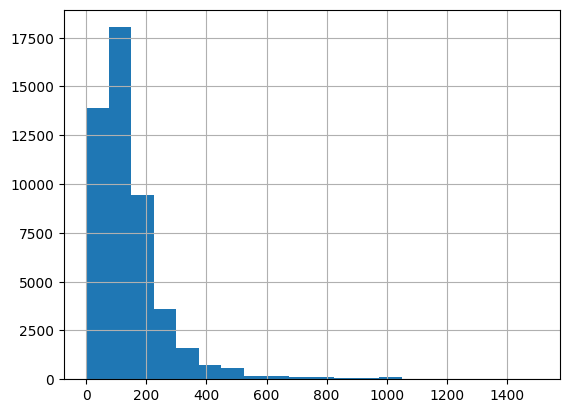

In [16]:
# Plotting the frequency of price values to look at the distribution
df['price'].hist(range = (0,1500) , bins=20)
plt.show()

In [17]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [18]:
lower_bound 

-90.0

In [19]:
upper_bound


334.0

In [20]:
# Removing Outliers
df = df[df['price'] < 334]

In [21]:
df.isnull().sum()

id                                0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [22]:
# Taking a look at how listings are distributed across neighborhood groups
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        19501
Brooklyn         19415
Queens            5567
Bronx             1070
Staten Island      365
Name: count, dtype: int64

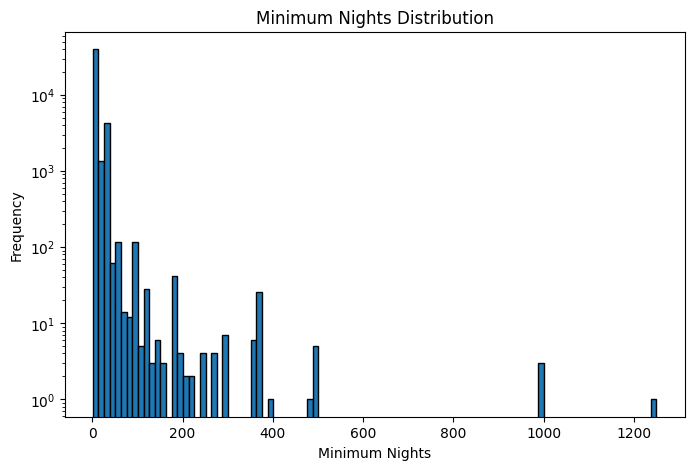

In [23]:
# Plotting to see how the values of minimum nights are distributed
plt.figure(figsize=(8,5))
df['minimum_nights'].plot(kind='hist', bins=100, edgecolor='black', log=True)
plt.title("Minimum Nights Distribution")
plt.xlabel("Minimum Nights")
plt.show()

In [24]:
# Removing outliers
df = df[df['minimum_nights'] <= 365]

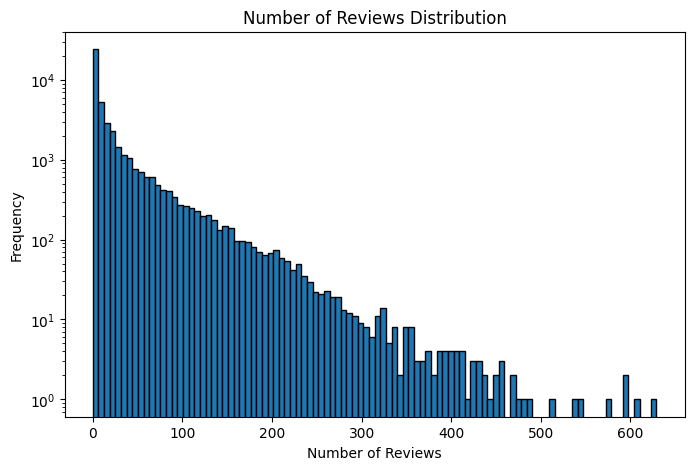

In [25]:
# Plotting to see how number of reviews is distributed
plt.figure(figsize=(8,5))
df['number_of_reviews'].plot(kind='hist', bins=100, edgecolor='black', log=True)
plt.title("Number of Reviews Distribution")
plt.xlabel("Number of Reviews")
plt.show()

In [26]:
# Removing Outliers
df = df[df['number_of_reviews' ] < 500]

## Feature Engineering

In [27]:
# Creating a new feature that identifies wether an entry is considered coastal or not
def is_coastal(lat, lon):
    if lon < -73.95 or lon > -73.85 or lat < 40.6 or lat > 40.85:
        return 1
    else:
        return 0

df['coastal'] = df.apply(lambda row: is_coastal(row['latitude'], row['longitude']), axis=1)

In [28]:
# Creating a new feature that merges together the number of reviews with the price, to better resemble the profit
df['review_price'] = df['number_of_reviews']*df['price']

In [29]:
# Creating a new feature that shows the minimum amount of money needed to book at that host
df['Minimum Charge'] = df['minimum_nights']* df['price']

In [30]:
df['Minimum Charge'].value_counts()

Minimum Charge
300     1114
150     1017
100      981
200      890
600      720
        ... 
9675       1
1216       1
4850       1
1178       1
2350       1
Name: count, Length: 1745, dtype: int64

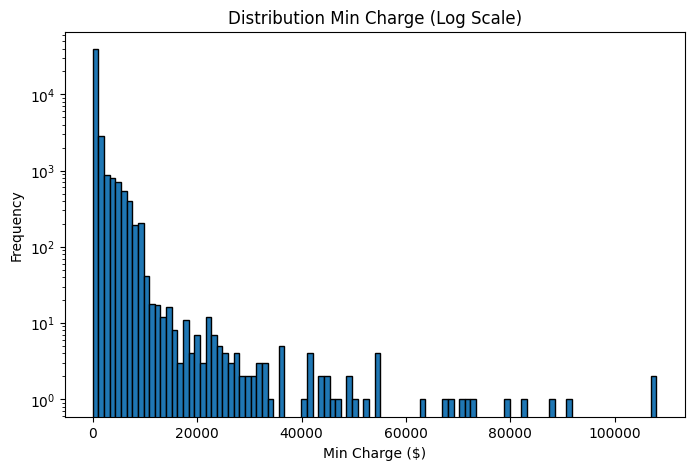

In [31]:
# Plotting to see the distribution of minimum charge
plt.figure(figsize=(8,5))
df['Minimum Charge'].plot(kind='hist', bins=100, edgecolor='black', log=True)
plt.title("Distribution Min Charge (Log Scale)")
plt.xlabel("Min Charge ($)")
plt.show()

In [32]:
# Removing outliers
df = df[df['Minimum Charge'] < 150000]

# Exploratory Data Analysis

## Distributions

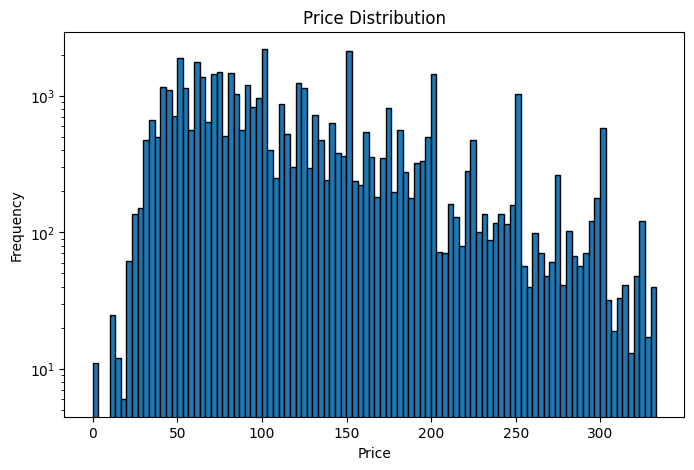

In [33]:
plt.figure(figsize=(8,5))
df['price'].plot(kind='hist', bins=100, edgecolor='black', log=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

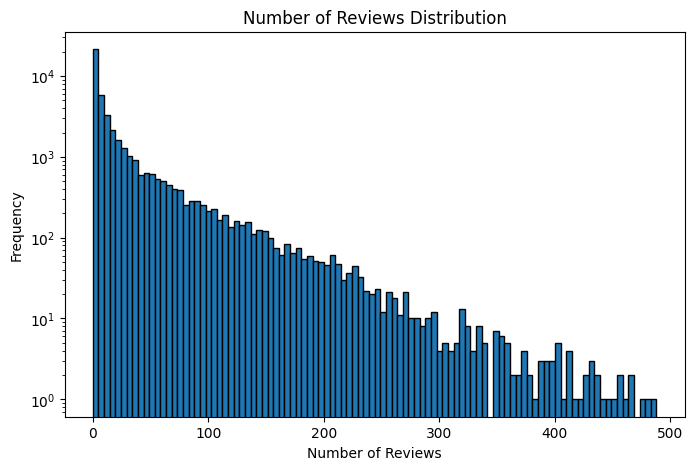

In [34]:
plt.figure(figsize=(8,5))
df['number_of_reviews'].plot(kind='hist', bins=100, edgecolor='black', log=True)
plt.title("Number of Reviews Distribution")
plt.xlabel("Number of Reviews")
plt.show()

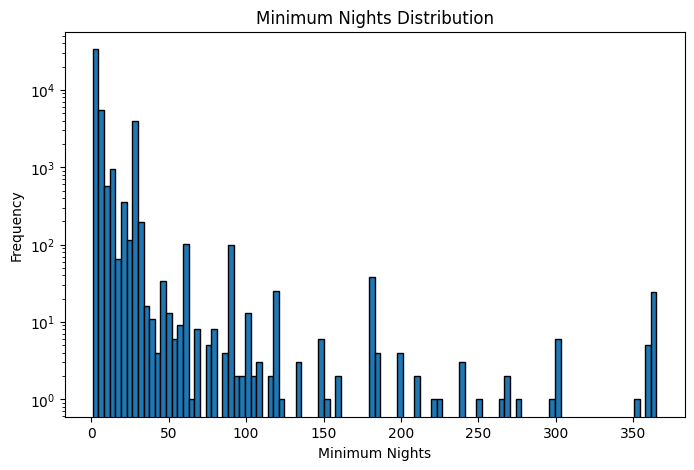

In [35]:
plt.figure(figsize=(8,5))
df['minimum_nights'].plot(kind='hist', bins=100, edgecolor='black', log=True)
plt.title("Minimum Nights Distribution")
plt.xlabel("Minimum Nights")
plt.show()

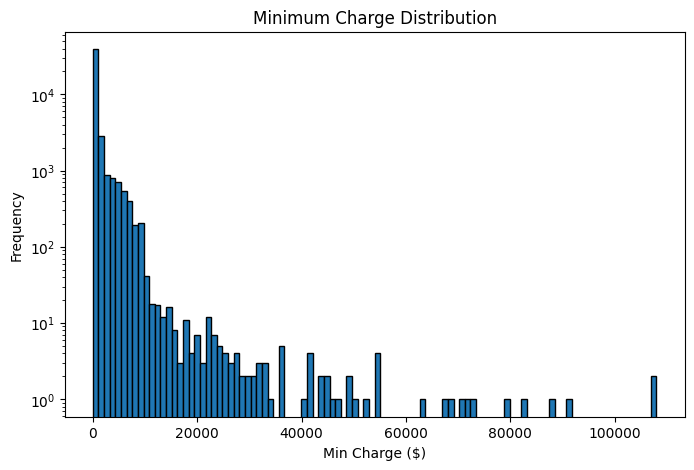

In [36]:
plt.figure(figsize=(8,5))
df['Minimum Charge'].plot(kind='hist', bins=100, edgecolor='black', log=True)
plt.title("Minimum Charge Distribution")
plt.xlabel("Min Charge ($)")
plt.show()

## Relationships

### Neighborhood Groups

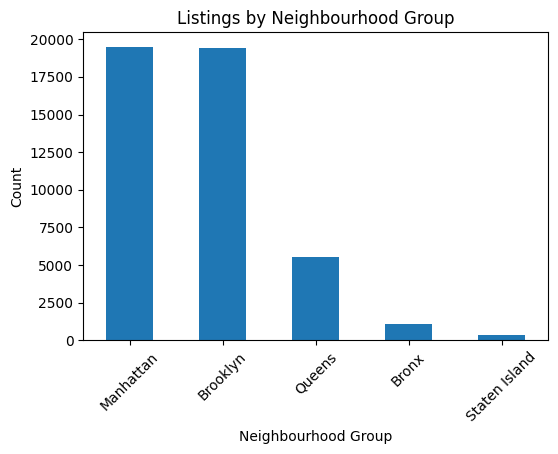

In [37]:
plt.figure(figsize=(6,4))
df['neighbourhood_group'].value_counts().plot(kind='bar')
plt.title("Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.xticks(rotation = 45) # to rotate labels name 45 degree
plt.ylabel("Count")
plt.show()

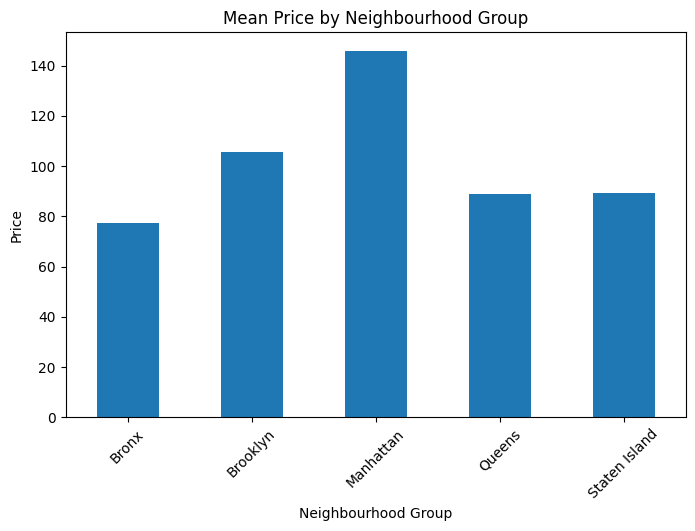

In [38]:
plt.figure(figsize=(8,5))
df.groupby('neighbourhood_group')['price'].mean().plot(kind='bar')
plt.title("Mean Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.xticks(rotation = 45)
plt.ylabel("Price")         
plt.show()

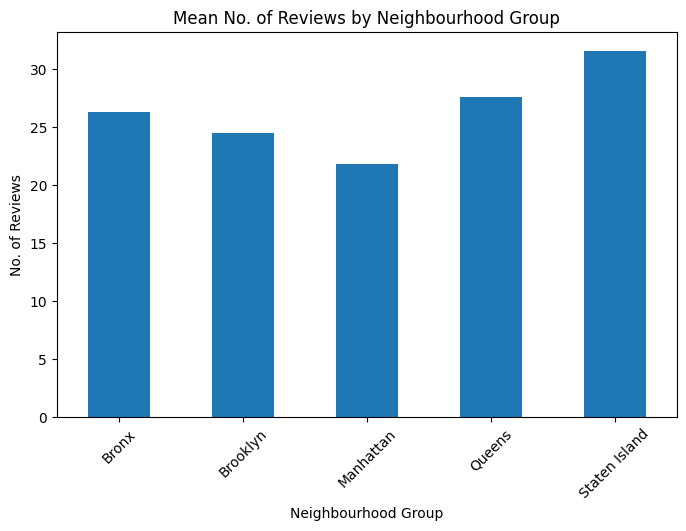

In [39]:
plt.figure(figsize=(8,5))
df.groupby('neighbourhood_group')['number_of_reviews'].mean().plot(kind='bar')
plt.title("Mean No. of Reviews by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.xticks(rotation = 45)
plt.ylabel("No. of Reviews")
plt.show()

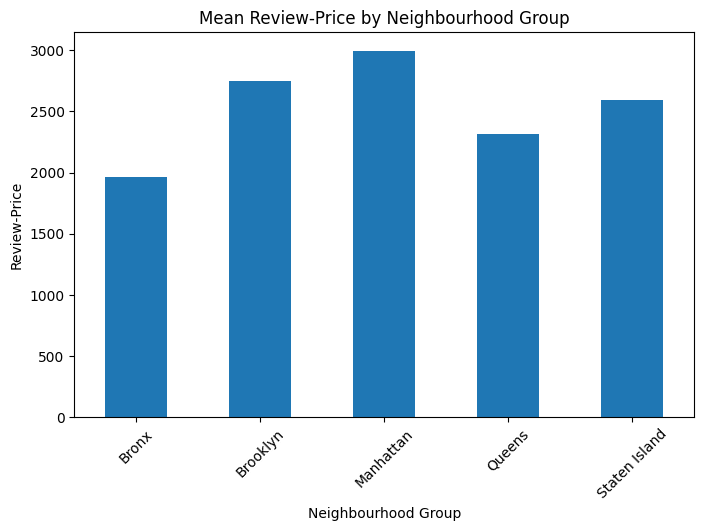

In [40]:
plt.figure(figsize=(8,5))
df.groupby('neighbourhood_group')['review_price'].mean().plot(kind='bar')
plt.title("Mean Review-Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.xticks(rotation = 45)
plt.ylabel("Review-Price")
plt.show()

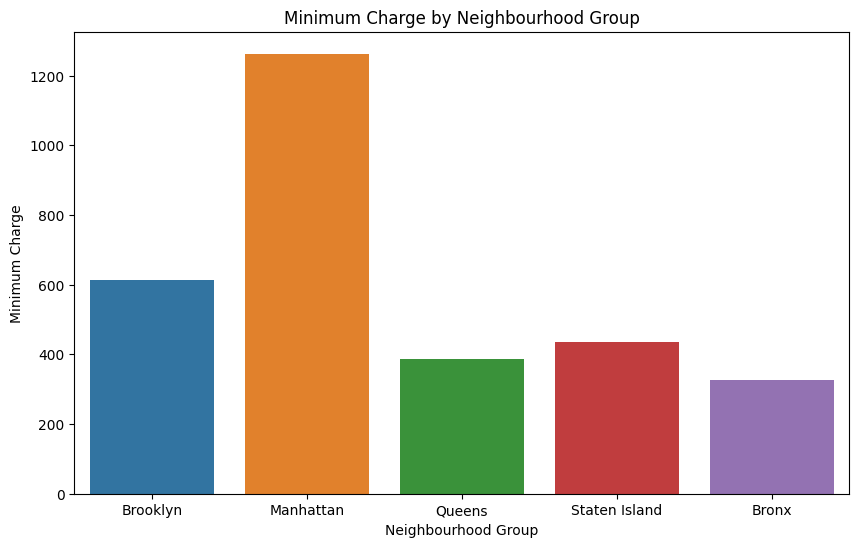

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="Minimum Charge",
    estimator=lambda x: x.mean(),
    errorbar=None
)

plt.title("Minimum Charge by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Minimum Charge")
plt.show()

### Key Finding: Staten Island Performance

- Staten Island has the **lowest number of listings** compared to all other neighborhood groups, with a huge difference.  
- Despite that, it has the **highest number of reviews**.  
- It also ranks **third in Reviews-to-Price ratio**, with only a very small gap compared to the top groups.  



**Implication:**  
Staten Island generates nearly the same revenue as other neighborhood groups **despite having far fewer listings**.  


If the number of listings in Staten Island increases, the overall revenue is very likely to increase as well.

### Room Type

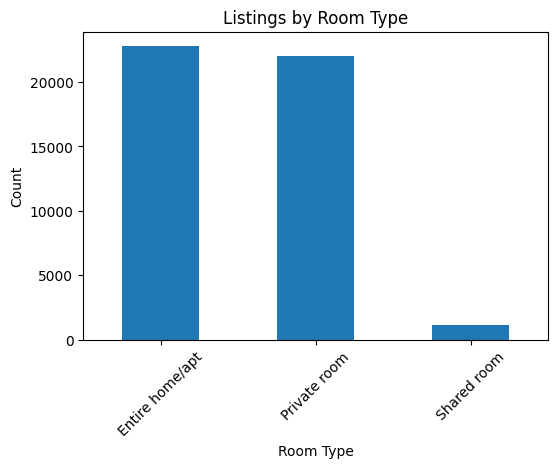

In [42]:
plt.figure(figsize=(6,4))
df['room_type'].value_counts().plot(kind='bar')
plt.title("Listings by Room Type")
plt.xlabel("Room Type")
plt.xticks(rotation = 45)
plt.ylabel("Count")
plt.show()

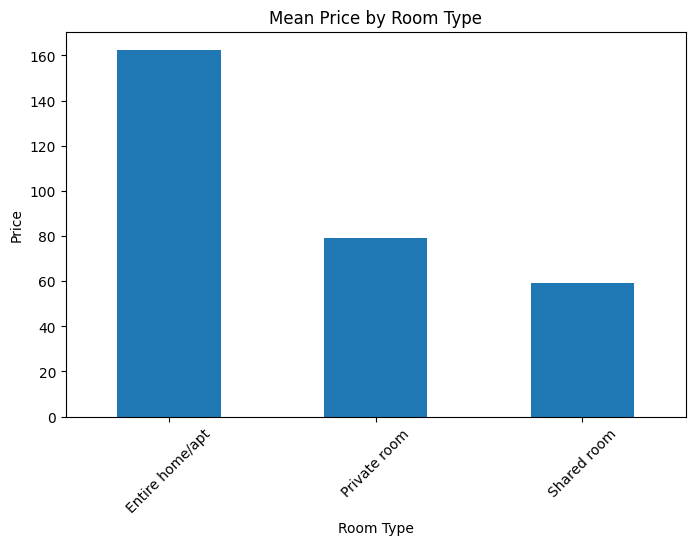

In [43]:
plt.figure(figsize=(8,5))
df.groupby('room_type')['price'].mean().plot(kind='bar')
plt.title("Mean Price by Room Type")
plt.ylabel("Price")
plt.xlabel("Room Type")
plt.xticks(rotation = 45)
plt.show()

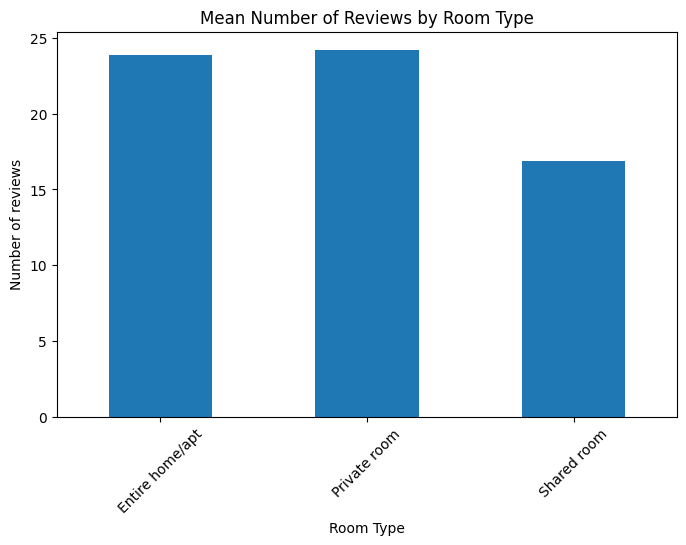

In [44]:
plt.figure(figsize=(8,5))
df.groupby('room_type')['number_of_reviews'].mean().plot(kind='bar')
plt.title("Mean Number of Reviews by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of reviews")
plt.xticks(rotation = 45)
plt.show()

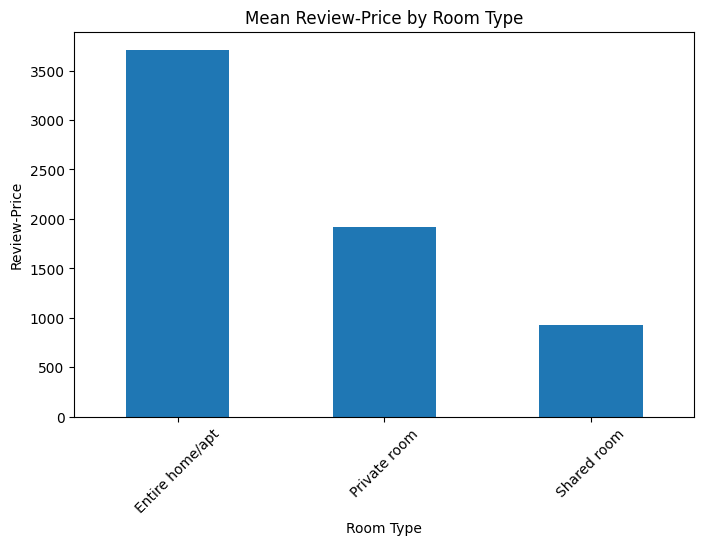

In [45]:
plt.figure(figsize=(8,5))
df.groupby('room_type')['review_price'].mean().plot(kind='bar')
plt.title("Mean Review-Price by Room Type")
plt.ylabel("Review-Price")
plt.xlabel("Room Type")
plt.xticks(rotation = 45)
plt.show()

### Neighborhood Group & Room Type

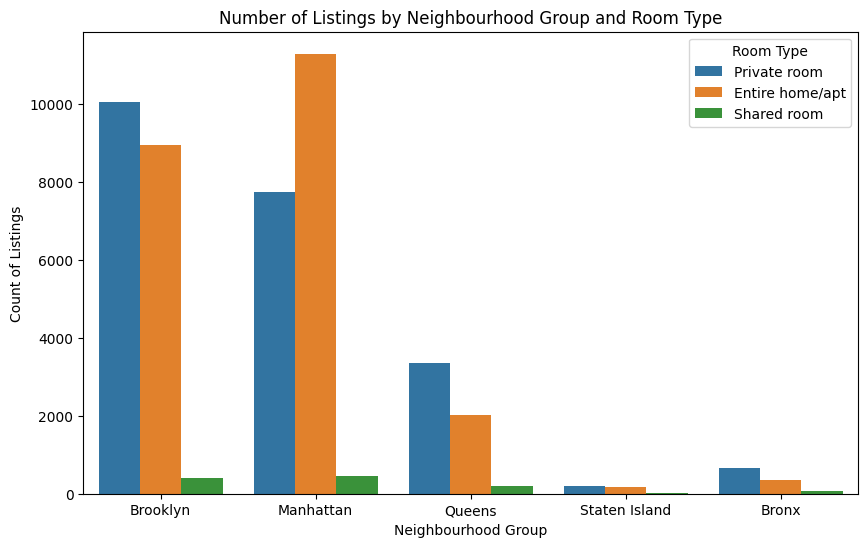

In [46]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="neighbourhood_group", hue="room_type")

plt.title("Number of Listings by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count of Listings")
plt.legend(title="Room Type")
plt.show()

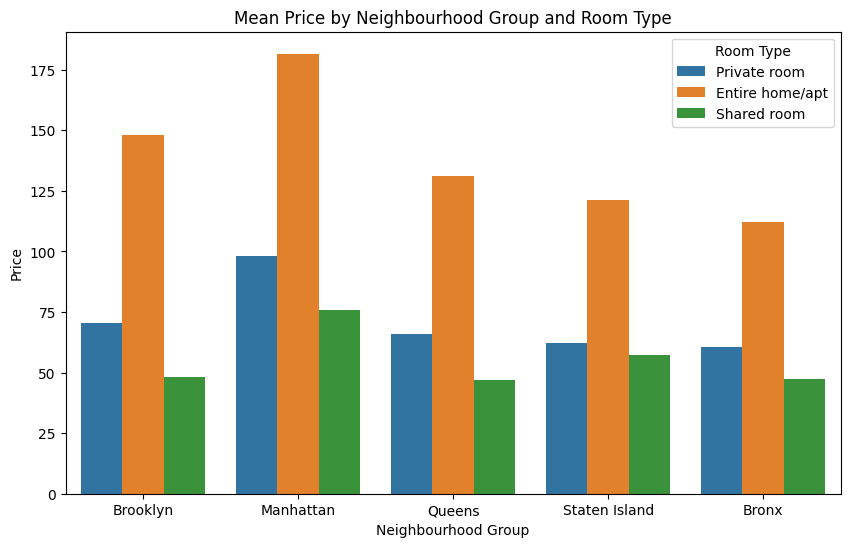

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    hue="room_type",
    estimator=lambda x: x.mean(),
    errorbar=None
)

plt.title("Mean Price by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")
plt.legend(title="Room Type")
plt.show()

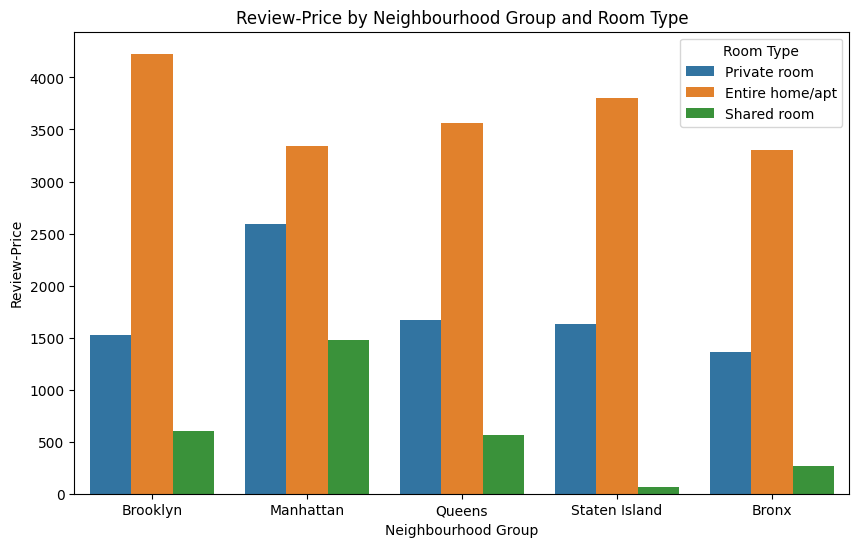

In [48]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="review_price",
    hue="room_type",
    estimator=lambda x: x.mean(),
    errorbar=None
)

plt.title("Review-Price by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Review-Price")
plt.legend(title="Room Type")
plt.show()

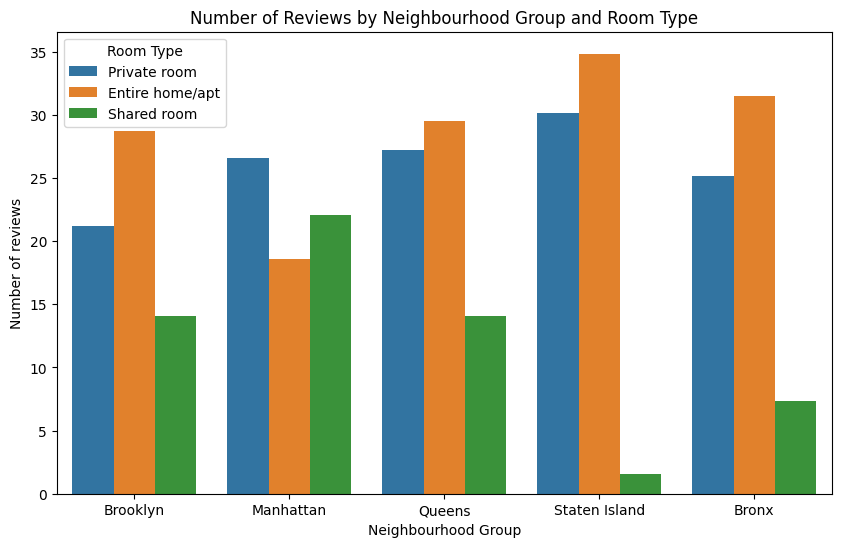

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="number_of_reviews",
    hue="room_type",
    estimator=lambda x: x.mean(),
    errorbar=None
)

plt.title("Number of Reviews by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of reviews")
plt.legend(title="Room Type")
plt.show()

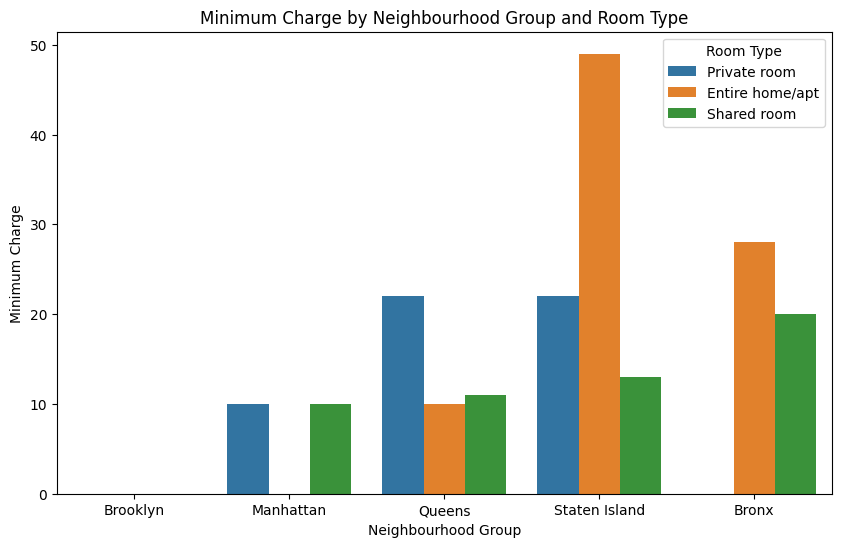

In [50]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="Minimum Charge",
    hue="room_type",
    estimator=lambda x: x.min(),
    errorbar=None
)

plt.title("Minimum Charge by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Minimum Charge")
plt.legend(title="Room Type")
plt.show()

### Conclusion 2

- In **Manhattan**, although the *Entire Home/Apartment* room type is the most common, it has the **least number of reviews** (even less than Shared Room).  
- Its slightly higher value in terms of *Review-Price* is mainly due to its much higher price compared to the other two room types, not because of demand.  
- This suggests that in Manhattan, it would be **better to invest more in Private Rooms** rather than Entire Homes.  

- On the other hand, in the **other four Neighborhood Groups (Brooklyn, Queens, Bronx, Staten Island)**, the pattern is opposite:  
  - Although the number of *Entire Home/Apartment* listings is smaller than Private Rooms,  
  - They have a **larger number of reviews** and a **higher Review-Price**.  
- This implies that in these four Neighborhood Groups, it would be better to **increase the number of Entire Homes**.  


### Minimum Charge

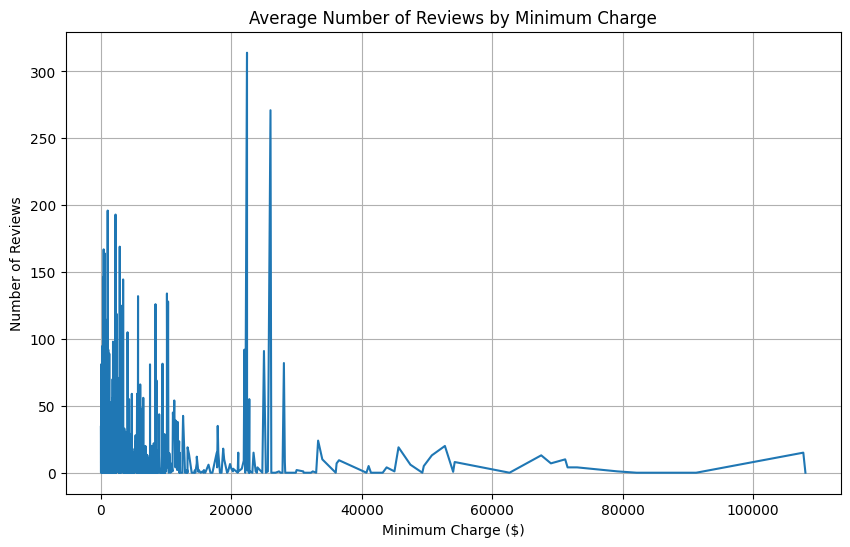

In [51]:
## Line chart between min charge and number of reviews
min_charge_reviews = df.groupby('Minimum Charge')['number_of_reviews'].mean().reset_index()
plt.figure(figsize=(10,6))
plt.plot(min_charge_reviews['Minimum Charge'], min_charge_reviews['number_of_reviews'])
plt.title("Average Number of Reviews by Minimum Charge")
plt.xlabel("Minimum Charge ($)")
plt.ylabel("Number of Reviews")
plt.grid()
plt.show()


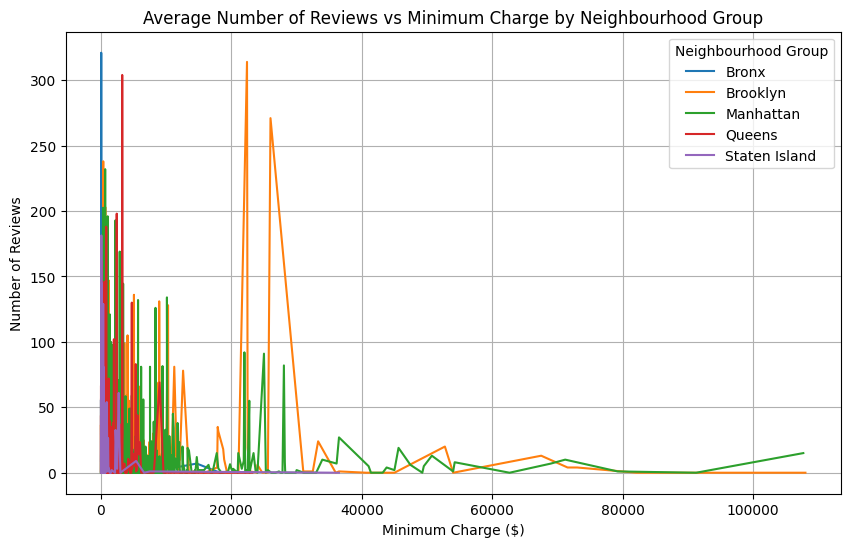

In [52]:
plt.figure(figsize=(10,6))

min_charge_reviews = (
    df.groupby(['Minimum Charge', 'neighbourhood_group'])['number_of_reviews']
    .mean()
    .reset_index()
)

for group in min_charge_reviews['neighbourhood_group'].unique():
    subset = min_charge_reviews[min_charge_reviews['neighbourhood_group'] == group]
    plt.plot(subset['Minimum Charge'], subset['number_of_reviews'], label=group)

plt.title("Average Number of Reviews vs Minimum Charge by Neighbourhood Group")
plt.xlabel("Minimum Charge ($)")
plt.ylabel("Number of Reviews")
plt.legend(title="Neighbourhood Group")
plt.grid()
plt.show()

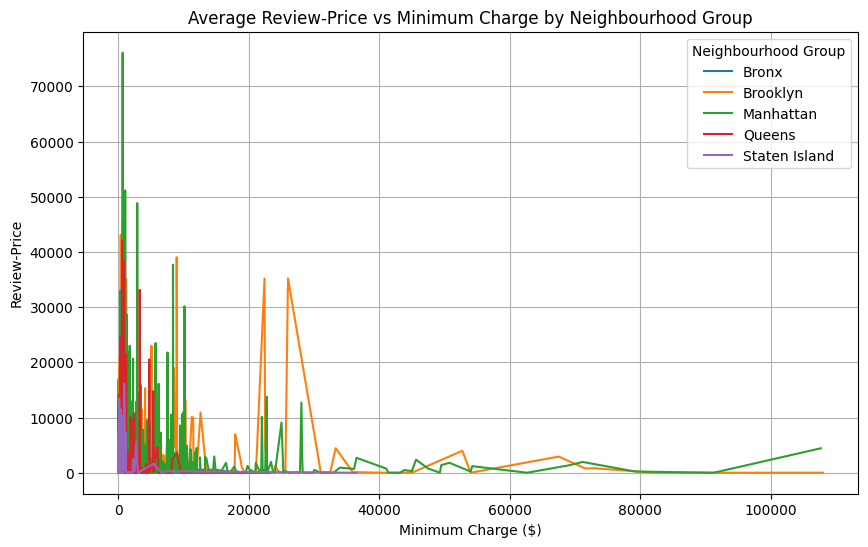

In [53]:
plt.figure(figsize=(10,6))

min_charge_reviews = (
    df.groupby(['Minimum Charge', 'neighbourhood_group'])['review_price']
    .mean()
    .reset_index()
)

for group in min_charge_reviews['neighbourhood_group'].unique():
    subset = min_charge_reviews[min_charge_reviews['neighbourhood_group'] == group]
    plt.plot(subset['Minimum Charge'], subset['review_price'], label=group)

plt.title("Average Review-Price vs Minimum Charge by Neighbourhood Group")
plt.xlabel("Minimum Charge ($)")
plt.ylabel("Review-Price")
plt.legend(title="Neighbourhood Group")
plt.grid()
plt.show()

### 3. Minimum Charge vs Reviews and Review-Price

When plotting **Minimum Charge** on the x-axis against either **Number of Reviews** or **Review-Price** on the y-axis, we observed a clear trend:  
- Higher reviews and higher Review-Price values tend to occur at **relatively lower Minimum Charges**.  
- Only a few exceptions deviate from this trend.  

This suggests that **affordable listings tend to attract more bookings and better performance in terms of revenue**.


### Price

### Top 10 Neighborhoods

In [54]:
df.groupby('neighbourhood') ['price'].mean().sort_values(ascending=False).head(20)

neighbourhood
Willowbrook           249.000000
Neponsit              237.000000
Breezy Point          213.333333
Tribeca               212.495327
NoHo                  205.290909
West Village          192.901235
Flatiron District     188.090909
Financial District    183.973926
Midtown               180.887916
Greenwich Village     180.058997
Mill Basin            179.750000
Murray Hill           179.559719
Chelsea               178.653319
Theater District      176.380165
DUMBO                 174.750000
Nolita                169.048889
Battery Park City     166.118644
Gramercy              164.549342
SoHo                  164.358209
Vinegar Hill          164.161290
Name: price, dtype: float64

In [55]:
g1 = df.groupby('neighbourhood') ['number_of_reviews'].mean().sort_values(ascending=False).head(10).reset_index()

g1['neighbourhood_group'] = df['neighbourhood_group']

In [56]:
g10 = df.groupby('neighbourhood') ['review_price'].mean().sort_values(ascending=False).head(10).reset_index()

g10['neighbourhood_group'] = df['neighbourhood_group']

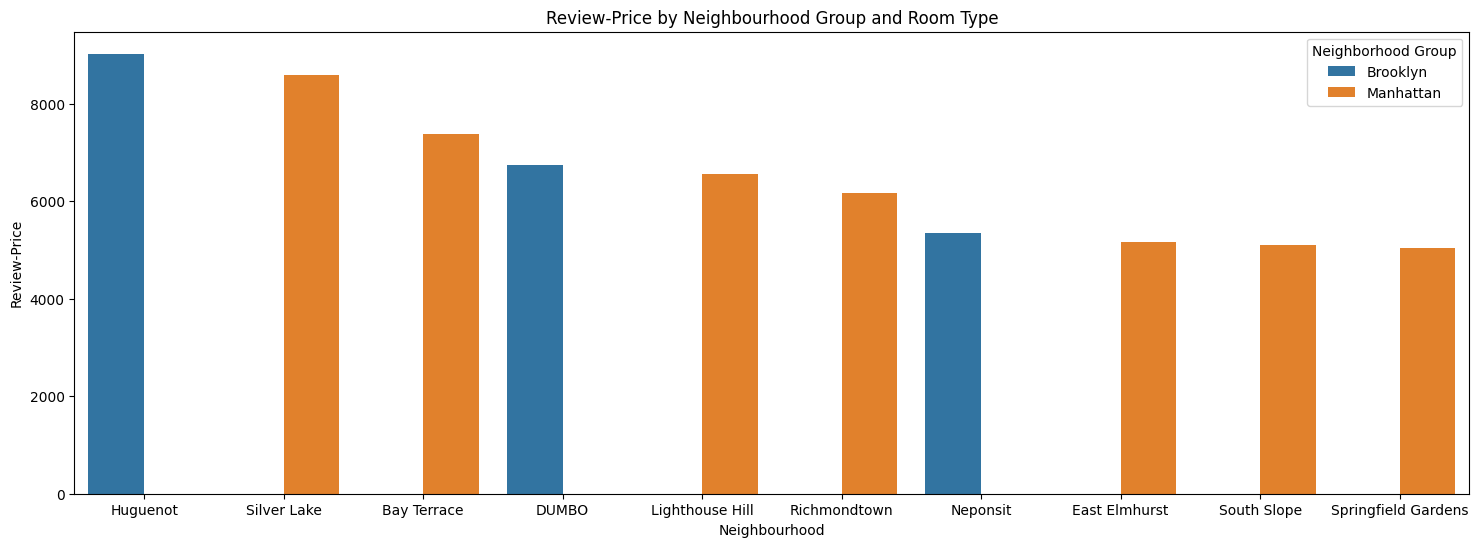

In [57]:
plt.figure(figsize=(18,6))
sns.barplot(
    data=g10,
    x="neighbourhood",
    y="review_price",
    hue="neighbourhood_group",
    estimator=lambda x: x.mean(),
    errorbar=None
)

plt.title("Review-Price by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood")
plt.ylabel("Review-Price")
plt.legend(title="Neighborhood Group")
plt.show()

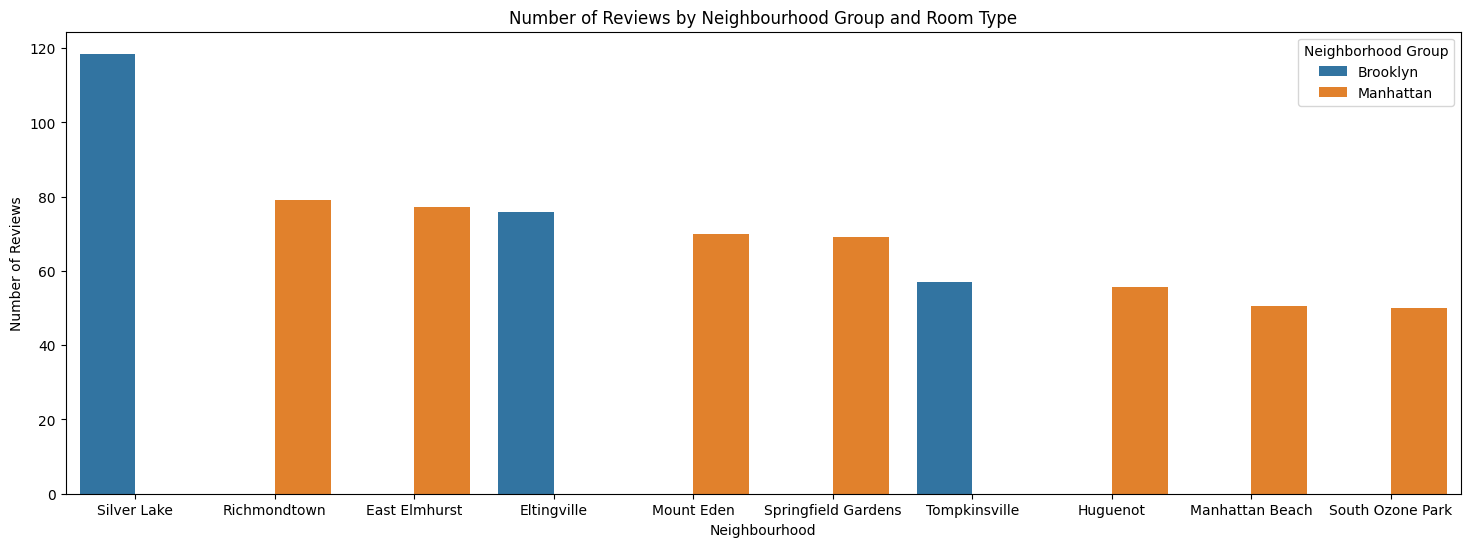

In [58]:
plt.figure(figsize=(18,6))
sns.barplot(
    data=g1,
    x="neighbourhood",
    y="number_of_reviews",
    hue="neighbourhood_group",
    estimator=lambda x: x.mean(),
    errorbar=None
)

plt.title("Number of Reviews by Neighbourhood Group and Room Type")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of Reviews")
plt.legend(title="Neighborhood Group")
plt.show()

### Host Listings Count

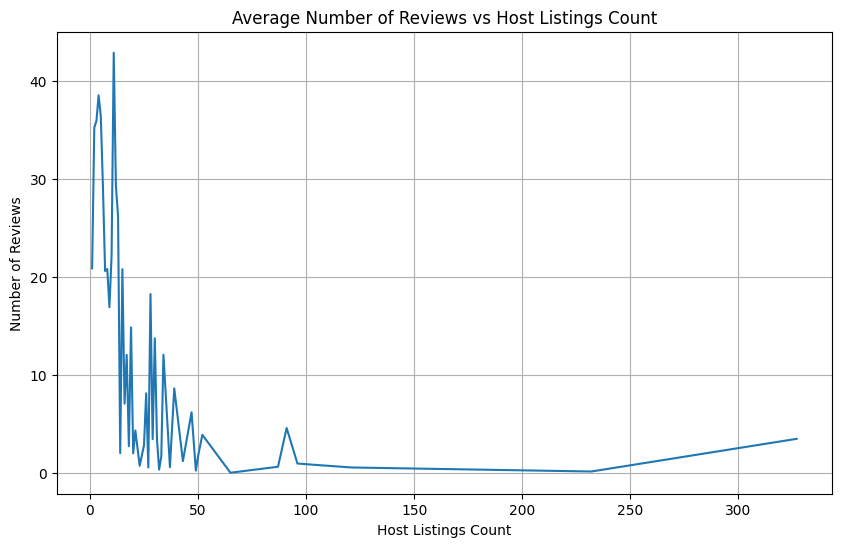

In [59]:
host_listings_reviews = df.groupby('calculated_host_listings_count')['number_of_reviews'].mean().reset_index()
plt.figure(figsize=(10,6))
plt.plot(host_listings_reviews['calculated_host_listings_count'], host_listings_reviews['number_of_reviews'])
plt.title("Average Number of Reviews vs Host Listings Count")
plt.xlabel("Host Listings Count")
plt.ylabel("Number of Reviews")
plt.grid()
plt.show()

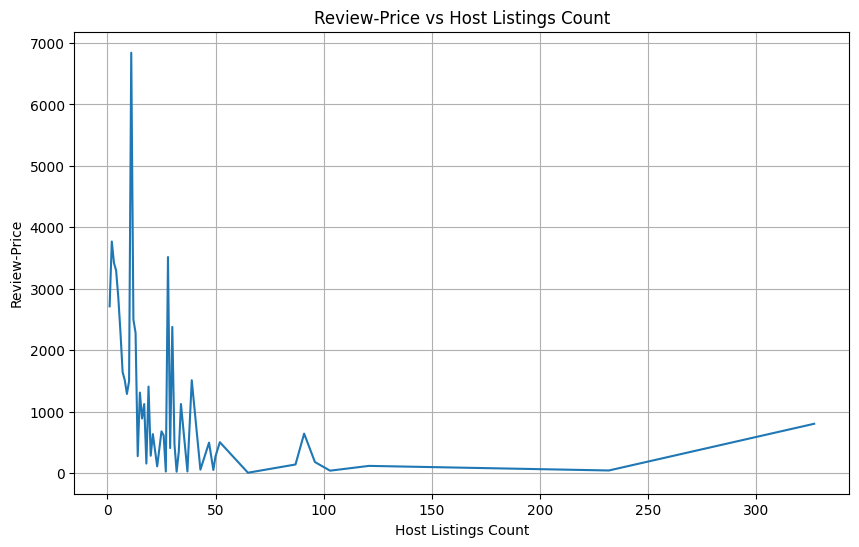

In [60]:
host_listings_reviews = df.groupby('calculated_host_listings_count')['review_price'].mean().reset_index()
plt.figure(figsize=(10,6))
plt.plot(host_listings_reviews['calculated_host_listings_count'], host_listings_reviews['review_price'])
plt.title("Review-Price vs Host Listings Count")
plt.xlabel("Host Listings Count")
plt.ylabel("Review-Price")
plt.grid()
plt.show()

### 4. Host Listings Count vs Reviews and Review-Price

We observed that both **Review-Price** and **Number of Reviews** decrease as the **Host Listings Count** increases beyond a certain threshold (around 50 listings).  

Possible explanations include:  
- Guests may **trust large-scale hosts less**, preferring smaller or individual hosts.  
- Hosts with many listings may **struggle to maintain quality**, leading to fewer reviews and lower performance.  


### Coastal vs Non-Coastal

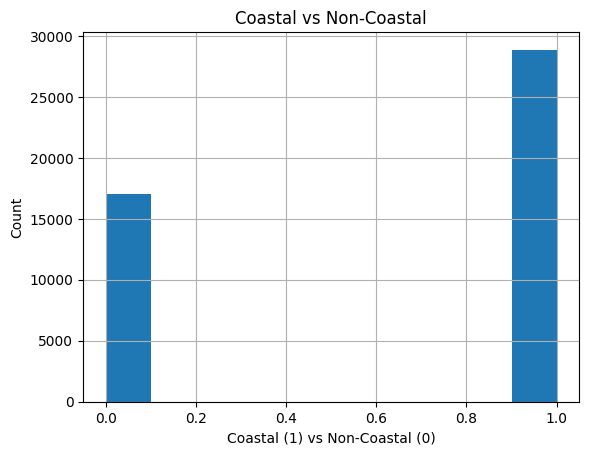

In [61]:
df['coastal'].hist()
plt.xlabel("Coastal (1) vs Non-Coastal (0)")
plt.title("Coastal vs Non-Coastal")
plt.ylabel("Count")
plt.show()

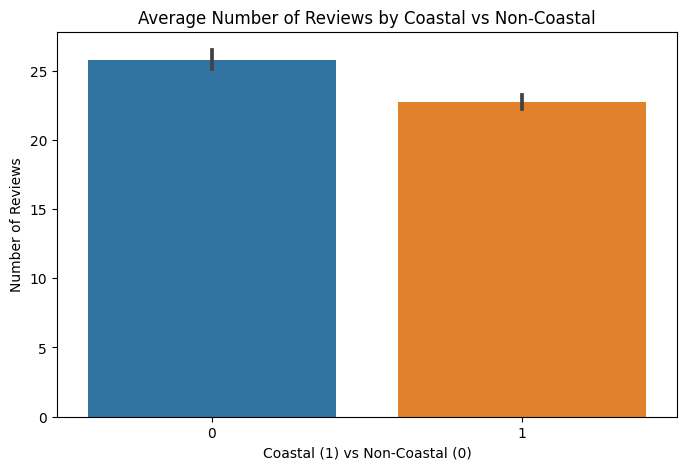

In [62]:
plt.figure(figsize=(8,5))
sns.barplot(x='coastal', y='number_of_reviews', data=df)
plt.title("Average Number of Reviews by Coastal vs Non-Coastal")
plt.xlabel("Coastal (1) vs Non-Coastal (0)")
plt.ylabel("Number of Reviews")
plt.show()


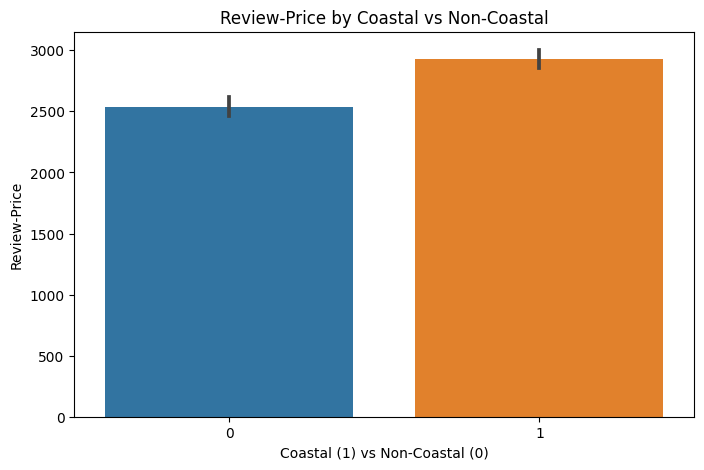

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(x='coastal', y='review_price', data=df)
plt.title("Review-Price by Coastal vs Non-Coastal")
plt.xlabel("Coastal (1) vs Non-Coastal (0)")
plt.ylabel("Review-Price")
plt.show()


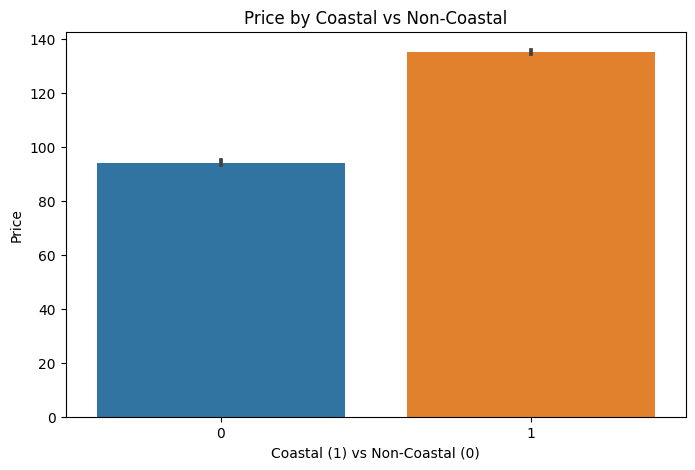

In [64]:
plt.figure(figsize=(8,5))
sns.barplot(x='coastal', y='price', data=df)
plt.title("Price by Coastal vs Non-Coastal")
plt.xlabel("Coastal (1) vs Non-Coastal (0)")
plt.ylabel("Price")
plt.show()


### 5. Coastal vs Non-Coastal Listings  

We found that the **number of listings** is higher in **coastal areas** compared to non-coastal areas.  
However:  
- The **number of reviews** is greater in non-coastal areas despite having fewer listings.  
- The **Review-Price** is slightly higher for coastal areas, mainly due to much higher prices rather than higher review engagement.  

This suggests that **non-coastal areas may be a better investment opportunity**, as they attract more reviews relative to their smaller number of listings, indicating stronger demand and engagement despite fewer listings.  
